# CONFIG

In [117]:
import os
import pandas as pd
import numpy as np

from maikol_utils.print_utils import print_separator


pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [118]:
from src.config.config import Configuration

CONFIG = Configuration()

# CODE

## Data

In [119]:
from maikol_utils.file_utils import list_dir_files

rng = np.random.default_rng(CONFIG.seed)

files, n = list_dir_files(CONFIG.all_path, recursive=True)
print(f"Found {n} files in {CONFIG.all_path}")

files = rng.choice(files, size=CONFIG.max_files, replace=False)
print(f"Selected {len(files)} files for processing.")


Found 2648 files in data/Dataset/all
Selected 100 files for processing.


Epoch 0:   0%|          | 0/58 [12:43<?, ?it/s]


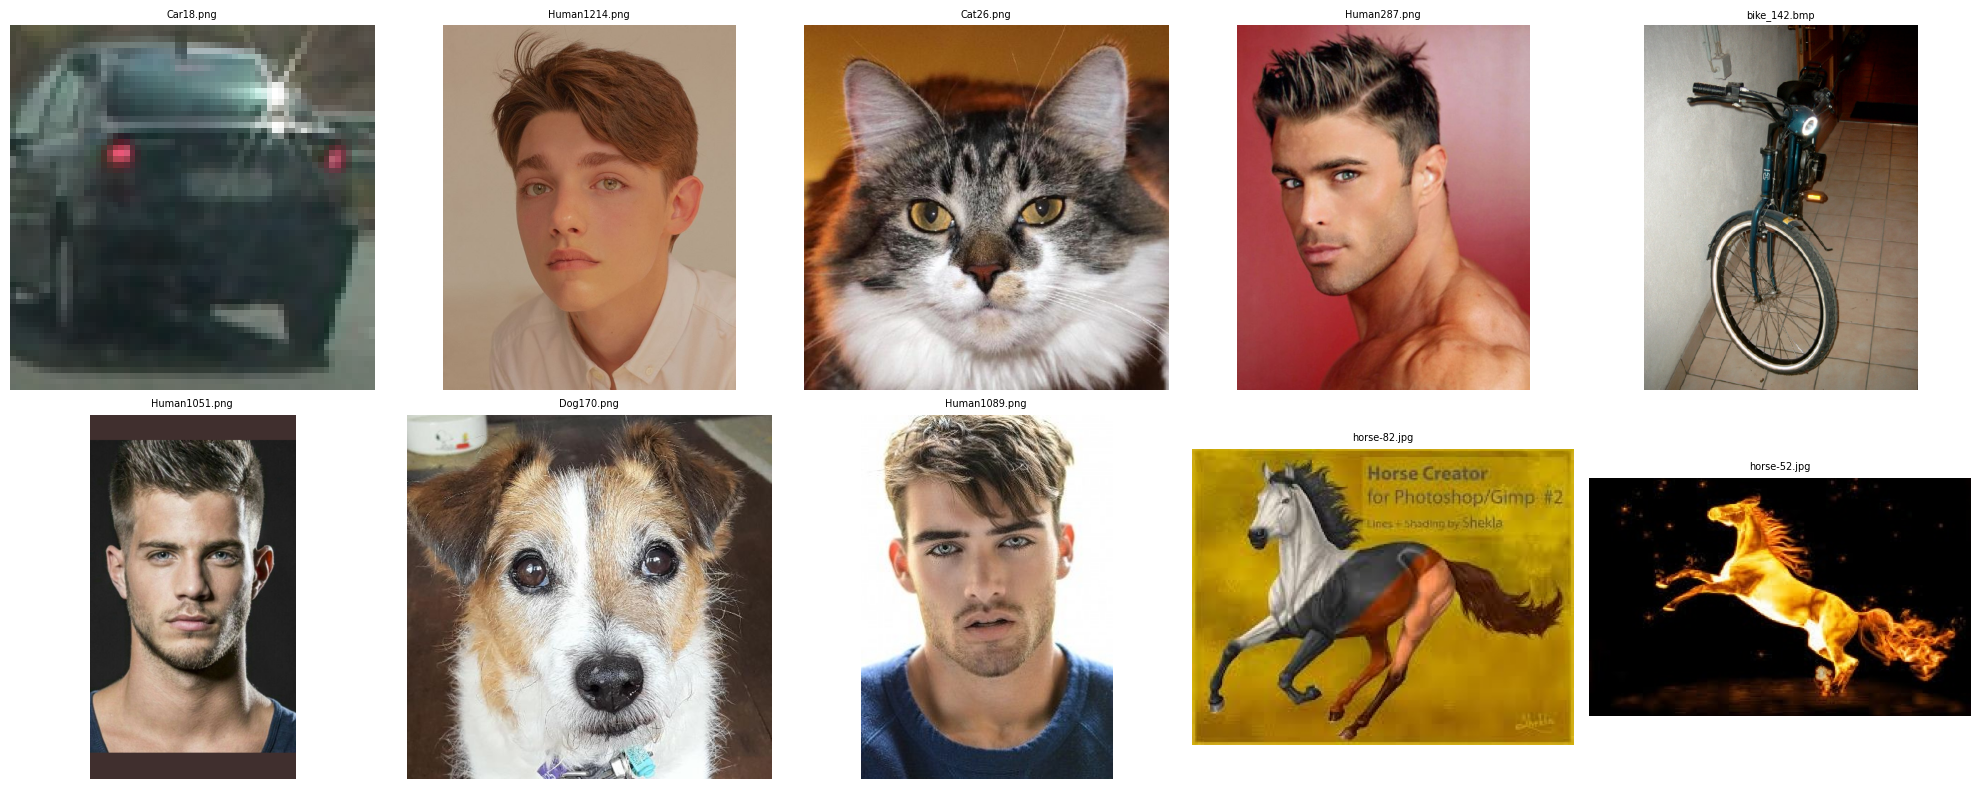

In [120]:
import matplotlib.pyplot as plt
from PIL import Image

rng = np.random.default_rng(CONFIG.seed)
sample = rng.choice(files, size=10, replace=False)

def show_images(images):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    for ax, path in zip(axes.flatten(), images):
        with Image.open(path) as img:
            ax.imshow(img)
        ax.axis("off")
        ax.set_title(os.path.basename(path), fontsize=7)

    plt.tight_layout()
    plt.show()

show_images(sample)


### Create partitions
- Convert all to jpg

In [ ]:
from src.data import create_partition
# create_partition(CONFIG, rng)

Train: 1854 images
Val: 397 images
Test: 397 images
________________________________________________________________
                     data/Dataset/img_train                     



/home/turbotowerlnx/Documents/Master/BIOM/venv/lib/python3.12/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Copying data/Dataset/img_train images:  90%|████████▉ | 1662/1854 [00:10<00:01, 161.15it/s]


KeyboardInterrupt: 

## Get all image crops

In [ ]:
import cv2
from concurrent.futures import ProcessPoolExecutor, as_completed

def get_all_image_crops(CONFIG: Configuration, image_path: str):
    crops = []
    if CONFIG.gray_scale:
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    else:
        img = cv2.imread(image_path)


    while img.shape[0] > CONFIG.crop_size and img.shape[1] > CONFIG.crop_size:
        crops.extend(get_image_crops(img, CONFIG.stride, CONFIG.crop_size))
        img = cv2.resize(
            img, 
            dsize=(
                int(img.shape[0] * CONFIG.subsample_factor), 
                int(img.shape[1] * CONFIG.subsample_factor)
            ), 
            interpolation=cv2.INTER_AREA
        )
    return crops

def get_image_crops(img: np.ndarray, stride: int, crop_size: int):
    h, w = img.shape[:2]
    crops = []
    for i in range(0, h - crop_size + 1, stride):
        for j in range(0, w - crop_size + 1, stride):
            crops.append(img[
                i:i + crop_size, 
                j:j + crop_size
            ])
    return crops



crops = get_all_image_crops(CONFIG, sample[7])


In [ ]:
import time

t1 = time.time()
all_crops_seq = [get_all_image_crops(CONFIG, img) for img in files]
t2 = time.time()
seq_time = t2 - t1

print(f"{seq_time:.2f}s  ({seq_time/len(files)*1000:.1f} ms/img)")

1.56s  (15.6 ms/img)


9997
[ 858 7731  891 6539 4384 4326 6970  941 2013 8579]


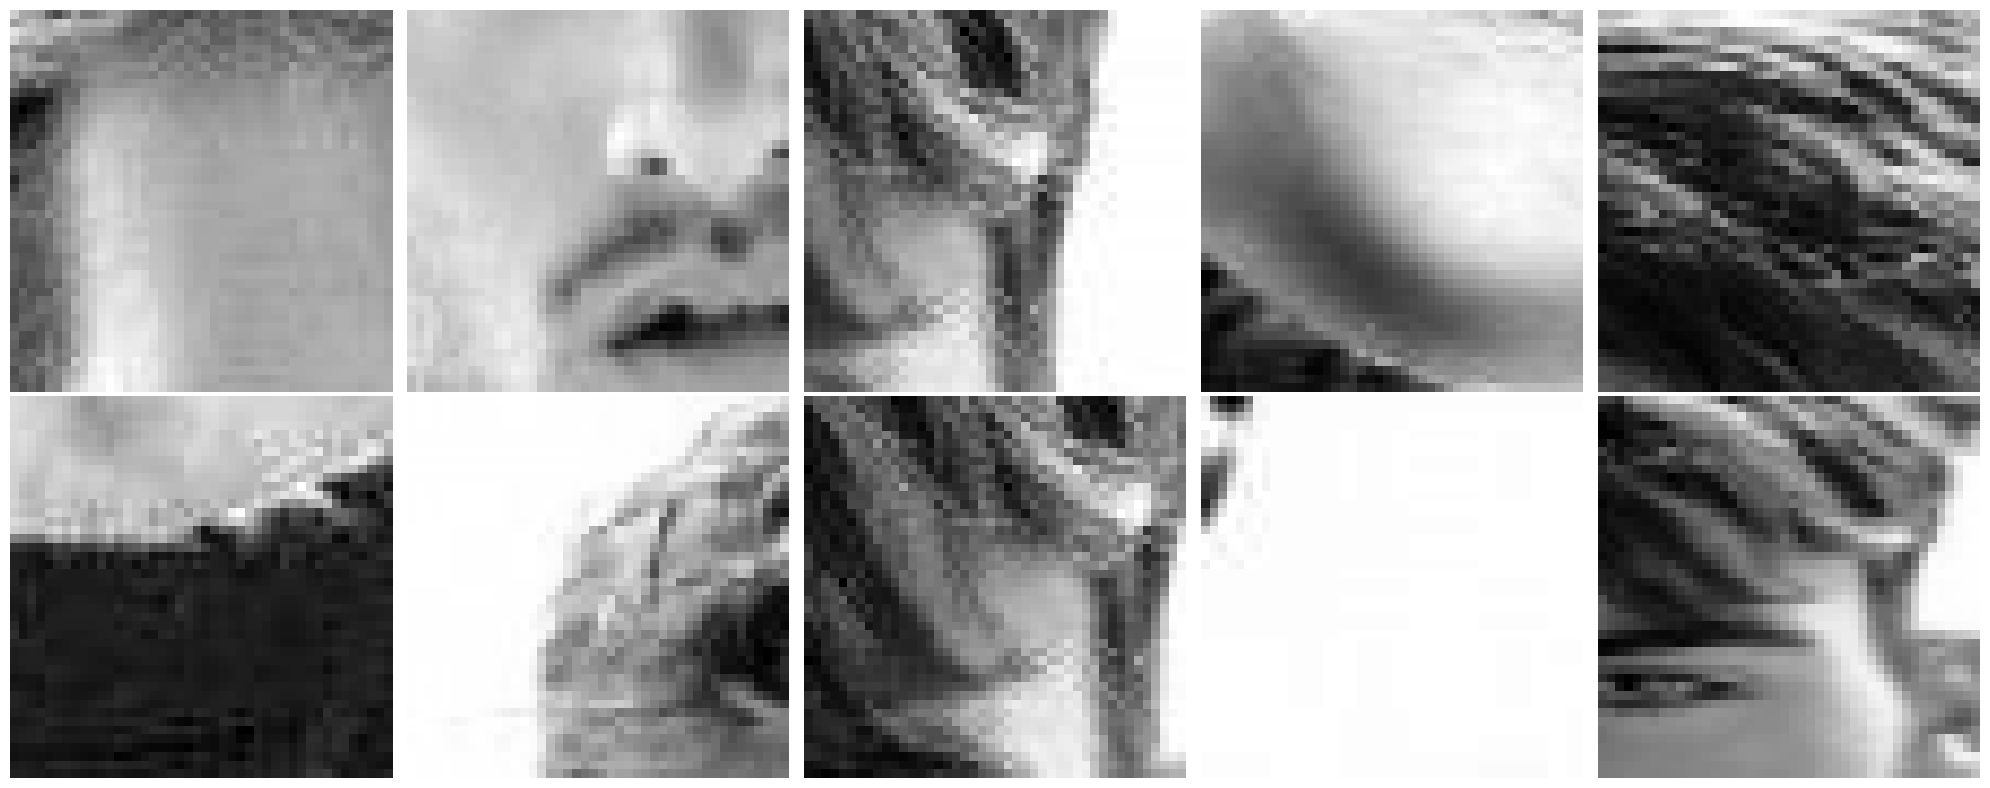

In [ ]:
def show_crops(crops_to_show):
    n = len(crops_to_show)
    cols = min(5, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, crop in zip(axes, crops_to_show):
        # grayscale (2D) — show directly; BGR (3D uint8) — convert to RGB
        if crop.ndim == 2:
            ax.imshow(crop, cmap="gray")
        else:
            crop_show = crop
            if crop.dtype != np.uint8:
                crop_show = np.clip(crop, 0, 255).astype(np.uint8)
            ax.imshow(cv2.cvtColor(crop_show, cv2.COLOR_BGR2RGB))
        ax.axis("off")

    for ax in axes[len(crops_to_show):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


print(len(crops))

rng = np.random.default_rng(CONFIG.seed)
k = min(10, len(crops))
idx = rng.choice(len(crops), size=k, replace=False)
print(idx)
sampled_crops = [crops[i] for i in idx]
show_crops(sampled_crops)


## Normalization

### Integral image

In [ ]:
from src.data import get_integral_image, get_integral_squared_image, get_integral_sum

integral = get_integral_image(crops[1])
integral_2 = get_integral_squared_image(crops[1])
# print(integral)
# print(integral_2)

print(get_integral_sum(integral, 0, 0, 10, 10))
print(get_integral_sum(integral_2, 0, 0, 10, 10))


30772
7825778


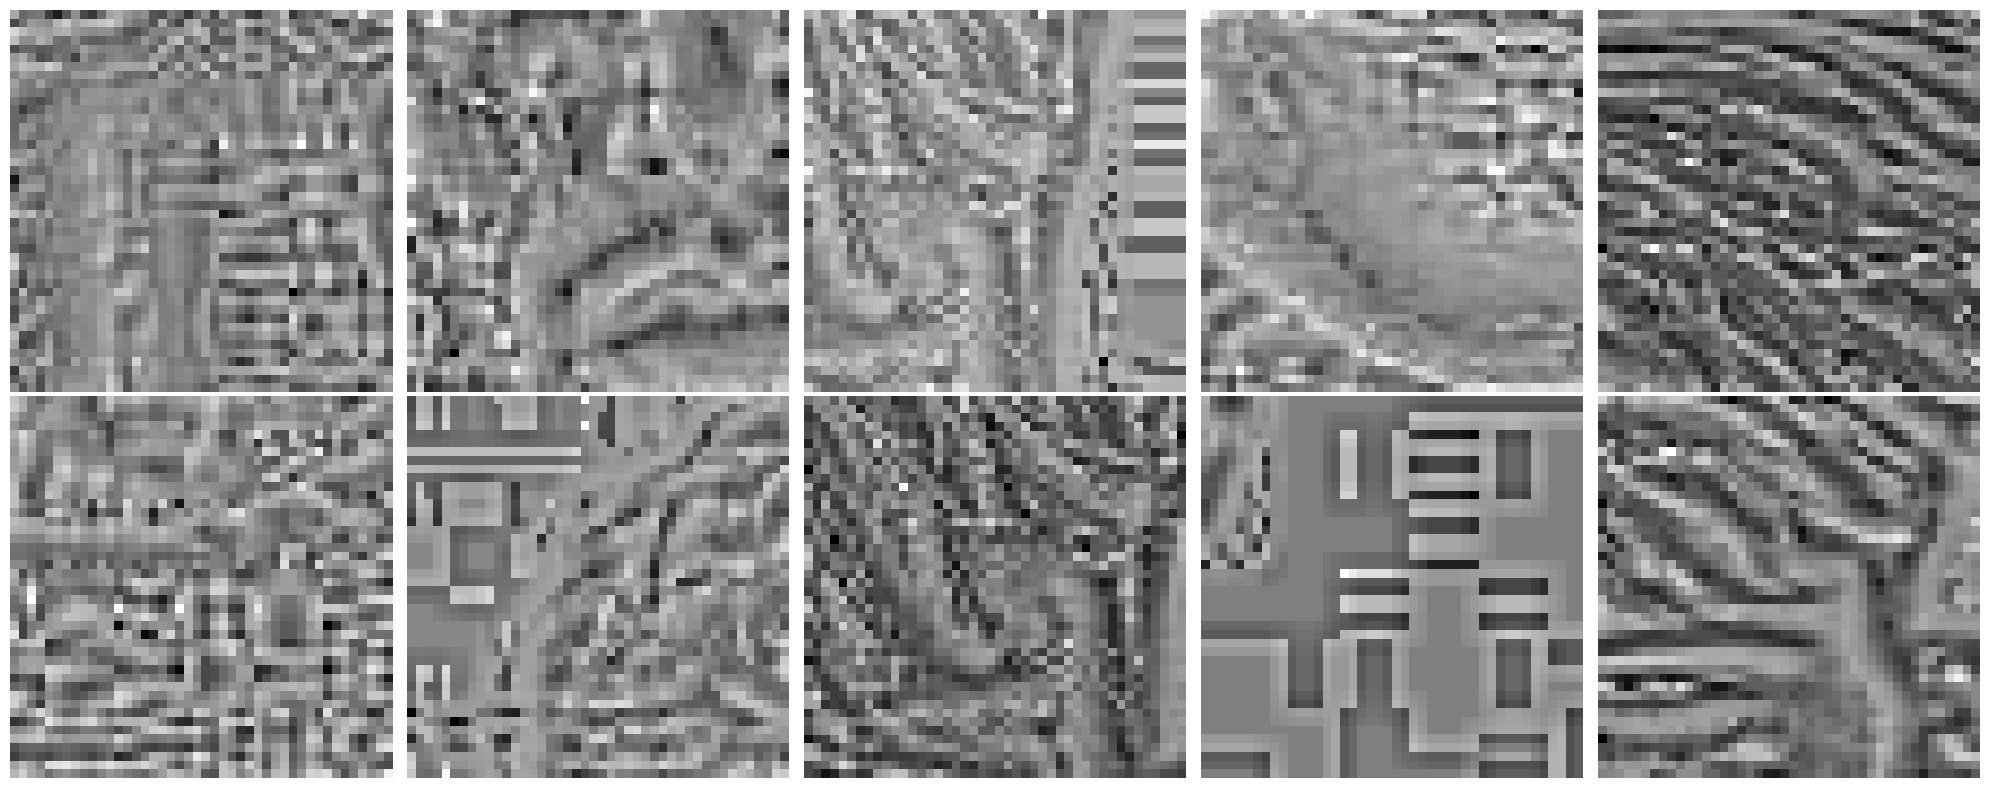

In [ ]:
from src.data import local_normalize_image


rng = np.random.default_rng(CONFIG.seed)
k = min(10, len(crops))
idx = rng.choice(len(crops), size=k, replace=False)
sampled_crops = [local_normalize_image(CONFIG, crops[i]) for i in idx]
show_crops(sampled_crops)


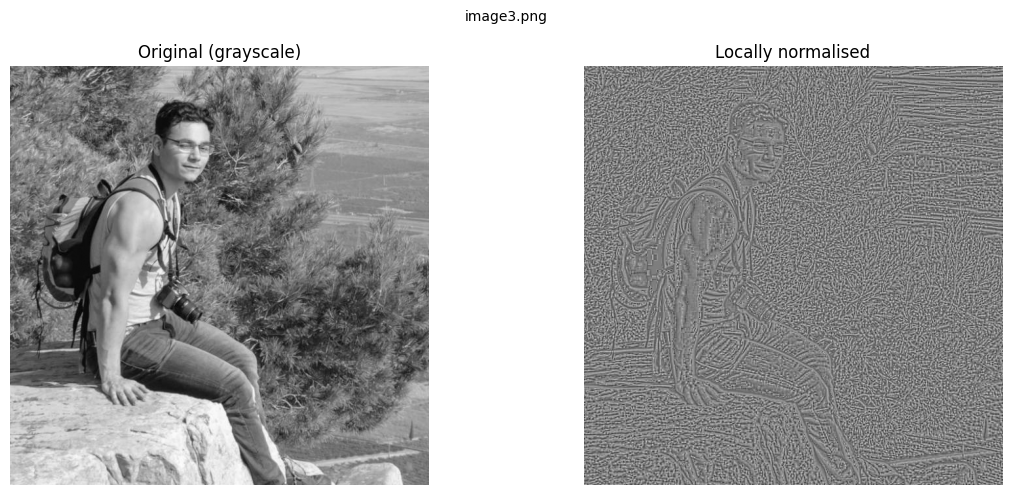

In [122]:

img_path = os.path.join("data", "image3.png")
img_bgr  = cv2.imread(img_path)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

img_norm = local_normalize_image(CONFIG, img_gray)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_gray, cmap="gray")
axes[0].set_title("Original (grayscale)")
axes[0].axis("off")

axes[1].imshow(img_norm, cmap="gray")
axes[1].set_title("Locally normalised")
axes[1].axis("off")

plt.suptitle(os.path.basename(img_path), fontsize=10)
plt.tight_layout()
plt.show()


## Neural network

En el paper original usan una RN normal sin convoluciones, vamos a probar con y sin ellas

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

# !pip install torchvision
import torchvision

import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# !pip install torchmetrics
import torchmetrics

### Original

In [112]:
class RowleyFaceNN(nn.Module):
    def __init__(self, in_channels=1):
        super(RowleyFaceNN, self).__init__()
        # 4 units: 10x10 subregions
        self.path1 = nn.Conv2d(in_channels, 1, kernel_size=10, stride=10)
        # 16 units: 5x5 subregions
        self.path2 = nn.Conv2d(in_channels, 1, kernel_size=5, stride=5)
        # 6 units: overlapping 20x5 horizontal stripes
        self.path3 = nn.Conv2d(in_channels, 1, kernel_size=(5, 20), stride=(3, 1))
        
        # 4 + 16 + 6 = 26 total hidden units
        self.fc = nn.Linear(26, 1)

    def forward(self, x):
        # The 1998 paper used Tanh activations instead of ReLU
        x1 = torch.flatten(torch.tanh(self.path1(x)), 1)
        x2 = torch.flatten(torch.tanh(self.path2(x)), 1)
        x3 = torch.flatten(torch.tanh(self.path3(x)), 1)
        
        x_cat = torch.cat((x1, x2, x3), dim=1)
        return torch.sigmoid(self.fc(x_cat))

### Custom CNN

In [113]:
class CNN(nn.Module):
    def __init__(self, in_channels, num_classes, out_size=(1, 1)):
        super(CNN, self).__init__()
        self.out_size = out_size
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=16, kernel_size=3, padding="same")
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding="same")
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=48, kernel_size=3, padding="same")

        self.fc = nn.Linear(48 * self.out_size[0] * self.out_size[1], num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))           
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = torch.nn.functional.adaptive_max_pool2d(x, output_size=self.out_size)
        x = torch.flatten(x, 1)
        return torch.sigmoid(self.fc(x))

## Dataset

In [114]:
from src.data import FACES_DATASET

## Train

In [115]:
import pytorch_lightning as pl
from torchmetrics.classification import BinaryAccuracy, BinaryF1Score


class FaceDetectionModule(pl.LightningModule):
    def __init__(self, CONFIG: Configuration, model: nn.Module = None):
        super().__init__()
        self.config = CONFIG
        self.model = model if model is not None else CNN(
            in_channels=1 if CONFIG.gray_scale else 3,
            num_classes=1,
        )
        self.criterion = nn.BCELoss()
        self.train_acc = BinaryAccuracy()
        self.val_acc   = BinaryAccuracy()
        self.test_acc  = BinaryAccuracy()
        self.val_f1    = BinaryF1Score()

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch):
        x     = batch["img"].float()
        y     = batch["label"].float().unsqueeze(1)
        y_hat = self(x)
        loss  = self.criterion(y_hat, y)
        preds = (y_hat > 0.5).squeeze(1)
        return loss, preds, batch["label"]

    def training_step(self, batch, batch_idx):
        loss, preds, labels = self._shared_step(batch)
        self.train_acc(preds, labels)
        self.log("train_loss", loss,           prog_bar=True, on_step=False, on_epoch=True)
        self.log("train_acc",  self.train_acc,  prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, preds, labels = self._shared_step(batch)
        self.val_acc(preds, labels)
        self.val_f1(preds, labels)
        self.log("val_loss", loss,          prog_bar=True)
        self.log("val_acc",  self.val_acc,   prog_bar=True)
        self.log("val_f1",   self.val_f1,    prog_bar=True)

    def test_step(self, batch, batch_idx):
        loss, preds, labels = self._shared_step(batch)
        self.test_acc(preds, labels)
        self.log("test_loss", loss)
        self.log("test_acc",  self.test_acc)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.config.lr,
            weight_decay=self.config.weight_decay,
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.config.epochs
        )
        return {"optimizer": optimizer, "lr_scheduler": scheduler}


class FaceDataModule(pl.LightningDataModule):
    def __init__(self, CONFIG: Configuration):
        super().__init__()
        self.config = CONFIG

    def setup(self, stage=None):
        train_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=self.config.aug_prob),
            transforms.RandomApply([
                transforms.RandomRotation(degrees=15),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
            ], p=self.config.aug_prob),
            transforms.ToTensor(),
        ])
        base_transform = transforms.Compose([
            transforms.ToTensor(),
        ])
        self.train_ds = FACES_DATASET("train", transform=train_transform, CONFIG=self.config)
        self.val_ds   = FACES_DATASET("val",   transform=base_transform,  CONFIG=self.config)
        self.test_ds  = FACES_DATASET("test",  transform=base_transform,  CONFIG=self.config)

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.config.batch_size, shuffle=True,
                          num_workers=0)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.config.batch_size, shuffle=False,
                          num_workers=0)

    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.config.batch_size, shuffle=False,
                          num_workers=0)


In [116]:
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

data_module  = FaceDataModule(CONFIG)
model_module = FaceDetectionModule(
    CONFIG=CONFIG,
    model=CNN(
        in_channels=1 if CONFIG.gray_scale else 3,
        num_classes=1,
    ),
)

trainer = pl.Trainer(
    max_epochs=CONFIG.epochs,
    accelerator="auto",
    devices="auto",
    callbacks=[
        ModelCheckpoint(
            monitor="val_loss",
            mode="min",
            save_top_k=1,
            filename="face-{epoch:02d}-{val_loss:.4f}",
        ),
        EarlyStopping(monitor="val_loss", patience=10, mode="min"),
    ],
    log_every_n_steps=10,
)

trainer.fit(model_module, datamodule=data_module)
trainer.test(model_module, datamodule=data_module)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type           | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model     | CNN            | 18.7 K | train | 0    
1 | criterion | BCELoss        | 0      | train | 0    
2 | train_acc | BinaryAccuracy | 0      | train | 0    
3 | val_acc   | BinaryAccuracy | 0      | train | 0    
4 | test_acc  | BinaryAccuracy | 0      | train | 0    
5 | val_f1    | BinaryF1Score  | 0      | train | 0    
-------------------------------------------------------------
18.7 K    Trainable params
0         Non-trainable params
18.7 K    Total params
0.075     Total estimated model params size (MB)
1

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type           | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model     | CNN            | 18.7 K | train | 0    
1 | criterion | BCELoss        | 0      | train | 0    
2 | train_acc | BinaryAccuracy | 0      | train | 0    
3 | val_acc   | BinaryAccuracy | 0      | train | 0    
4 | test_acc  | BinaryAccuracy | 0      | train | 0    
5 | val_f1    | BinaryF1Score  | 0      | train | 0    
-------------------------------------------------------------
18.7 K    Trainable params
0         Non-trainable params
18.7 K    Total params
0.075     Total estimated model params size (MB)
1

 - Total data train: 1854 images
 - Total data val: 397 images
 - Total data test: 397 images
Epoch 0:   2%|▏         | 1/58 [01:53<1:47:44,  0.01it/s, v_num=5]          

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type           | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model     | CNN            | 18.7 K | train | 0    
1 | criterion | BCELoss        | 0      | train | 0    
2 | train_acc | BinaryAccuracy | 0      | train | 0    
3 | val_acc   | BinaryAccuracy | 0      | train | 0    
4 | test_acc  | BinaryAccuracy | 0      | train | 0    
5 | val_f1    | BinaryF1Score  | 0      | train | 0    
-------------------------------------------------------------
18.7 K    Trainable params
0         Non-trainable params
18.7 K    Total params
0.075     Total estimated model params size (MB)
1

 - Total data train: 1854 images
 - Total data val: 397 images
 - Total data test: 397 images
Epoch 0:   2%|▏         | 1/58 [01:53<1:47:44,  0.01it/s, v_num=5]          

...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type           | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | model     | CNN            | 18.7 K | train | 0    
1 | criterion | BCELoss        | 0      | train | 0    
2 | train_acc | BinaryAccuracy | 0      | train | 0    
3 | val_acc   | BinaryAccuracy | 0      | train | 0    
4 | test_acc  | BinaryAccuracy | 0      | train | 0    
5 | val_f1    | BinaryF1Score  | 0      | train | 0    
-------------------------------------------------------------
18.7 K    Trainable params
0         Non-trainable params
18.7 K    Total params
0.075     Total estimated model params size (MB)
1

 - Total data train: 1854 images
 - Total data val: 397 images
 - Total data test: 397 images
Epoch 0:   2%|▏         | 1/58 [01:53<1:47:44,  0.01it/s, v_num=5]          


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/turbotowerlnx/Documents/Master/BIOM/venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
